In [1]:
! pip install emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.4 MB/s eta 0:00:00


In [2]:
! pip install corner

In [62]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from scipy import integrate
from scipy.stats import norm
from scipy.stats import uniform
import corner
import emcee
import time
import pandas as pd
from IPython.display import display, Math

In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/AstroStats/"
file_path = os.path.join(drive_path, "transient.npy")

Mounted at /content/drive


In [5]:
mydata = np.load(file_path)
print(mydata.shape)

(100, 3)


In [6]:
time = np.array(mydata[:, 0])
flux = np.array(mydata[:, 1])
flux_err = np.array(mydata[:, 2])

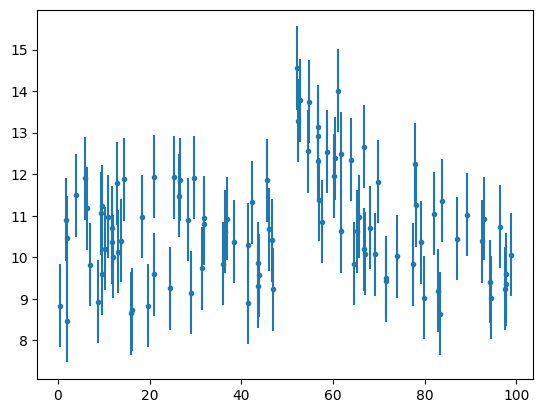

In [54]:
plt.errorbar(time, flux, yerr=flux_err, linestyle="", marker=".")
plt.show()

In [8]:
# only for vectorial data
# pars = [b, t0, A, a] correct order
def model(data, pars):
    result = np.zeros(len(data))
    for i in range(len(data)):
        if data[i]<pars[1]:
            result[i] = pars[0]
        else:
            result[i] = pars[0]+pars[2]*np.exp(-pars[3]*(data[i]-pars[1]))
    return result

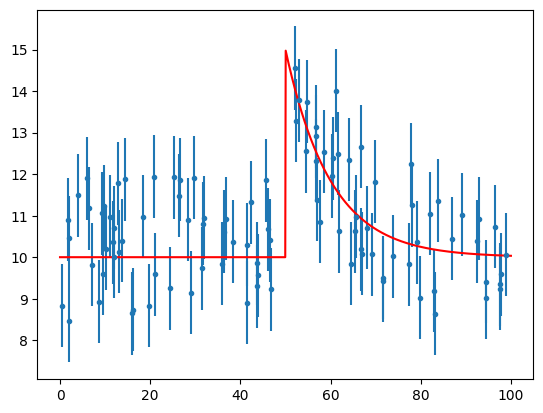

In [53]:
# cdc calculation of initial guesses
asse_x = np.linspace(0, 100, 1000)
asse_y = model(asse_x, [10, 50, 5, 0.1])
plt.errorbar(time, flux, yerr=flux_err, linestyle="", marker=".")
plt.plot(asse_x, asse_y, color="red")
plt.show()

In [10]:
# let's assume gaussian homoscedastic errors
def logLikelihood(pars, x, y, yerr):
    y_model = model(x, pars)
    if np.any(np.isnan(y_model)) or np.any(~np.isfinite(y_model)):
      return -np.inf
    else:
      return -0.5 * np.sum(((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2))

In [11]:
def Prior(pars):
    prior_b = uniform.pdf(pars[0], loc=0.0, scale=50.0)
    prior_t0 = uniform.pdf(pars[1], loc=0.0, scale=100.0)
    prior_A = uniform.pdf(pars[2], loc=0.0, scale=50.0)
    prior_ln_a = uniform.pdf(pars[3], loc=-5.0, scale=10.0)
    return  prior_b * prior_t0 * prior_A * (prior_ln_a/pars[3])

# emcee wants ln of posterior pdf
def logPosterior(pars, x, y, yerr):
    lp = np.log(Prior(pars))
    if not np.isfinite(lp):
      return -np.inf
    else:
      return logLikelihood(pars, x, y, yerr) + lp

In [12]:
# emcee combines multiple "walkers", each of which is its own MCMC chain. The number of trace results will be nwalkers x nsteps.
ndim = 4  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers (at least twice the number of dimensions)
nsteps = 50000 # number of MCMC steps to take **for each walker**

# initialize theta (inizializzare i camminatori attorno a un punto scelto a occhio nello spazio dei parametri,
# ma con una piccola variazione casuale, così non partono tutti esattamente dallo stesso).
np.random.seed(0)
starting_guesses = np.array([10, 50, 5, 0.1])+1e-2*np.random.randn(nwalkers, ndim)

# the function call where all the work happens:
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, flux_err))
sampler.run_mcmc(starting_guesses, nsteps)

print("done")

<ipython-input-11-302d500fe42c>:10: RuntimeWarning: invalid value encountered in log
  lp = np.log(Prior(pars))
<ipython-input-11-302d500fe42c>:10: RuntimeWarning: divide by zero encountered in log
  lp = np.log(Prior(pars))


done


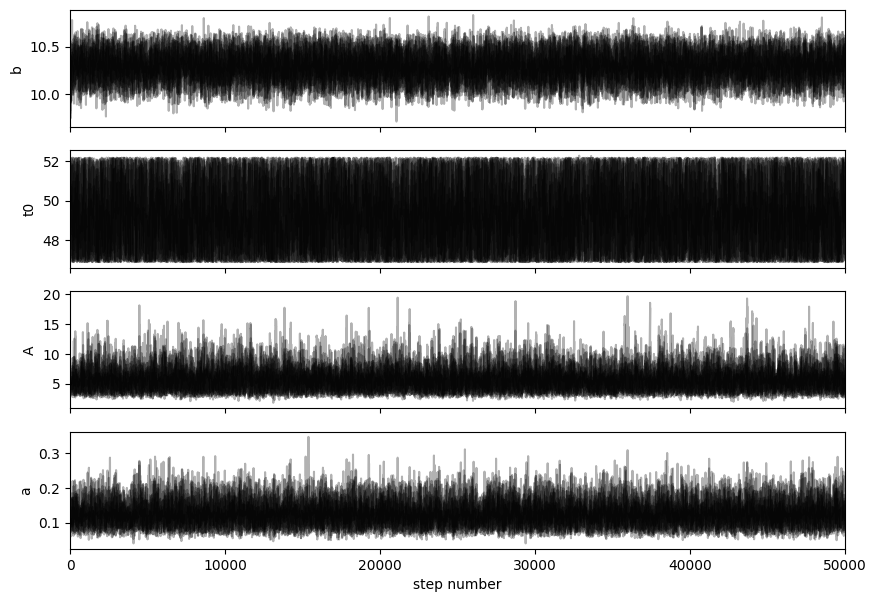

In [13]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["b","t0","A","a"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("step number");

In [42]:
# Now take one point every autocorrelation lenght
tau = sampler.get_autocorr_time()
print(tau)

[65.38980248 88.87341318 91.72988131 76.34746271]


In [43]:
flat_samples = sampler.get_chain(discard=int(nsteps/10), thin=int(np.ceil(np.max(tau))), flat=True)
print(flat_samples.shape)

(4890, 4)


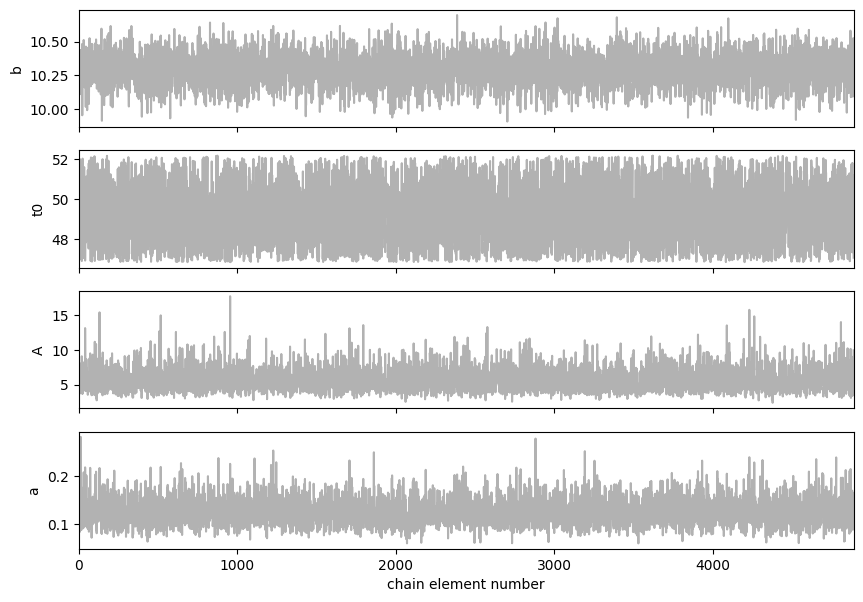

In [44]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
labels = ["b","t0","A","a"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples))
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("chain element number");

In [45]:
b_q05, b_q50, b_q95 = np.percentile(flat_samples[:, 0], [5, 50, 95])
t0_q05, t0_q50, t0_q95 = np.percentile(flat_samples[:, 1], [5, 50, 95])
A_q05, A_q50, A_q95 = np.percentile(flat_samples[:, 2], [5, 50, 95])
a_q05, a_q50, a_q95 = np.percentile(flat_samples[:, 3], [5, 50, 95])

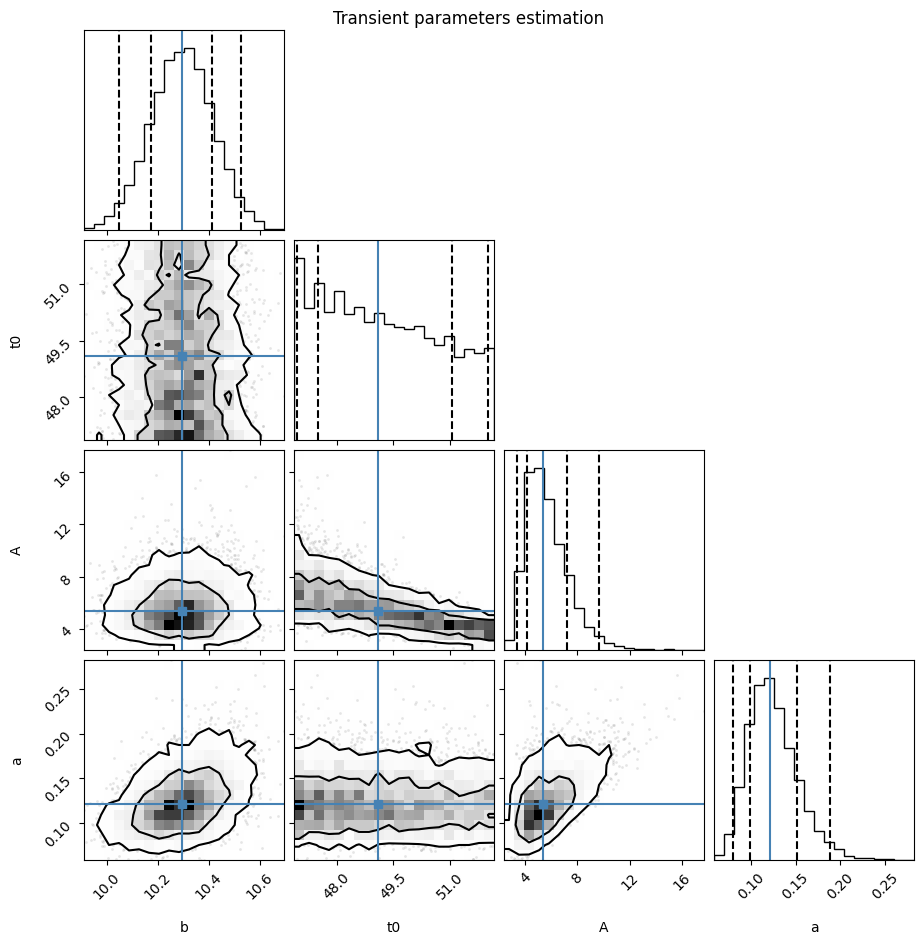

In [46]:
fig = corner.corner(flat_samples, labels=labels, quantiles=(0.025, 0.16, 0.84, 0.975), levels=(0.68, 0.95), truths=(b_q50, t0_q50, A_q50, a_q50))
fig.suptitle("Transient parameters estimation")
plt.show()

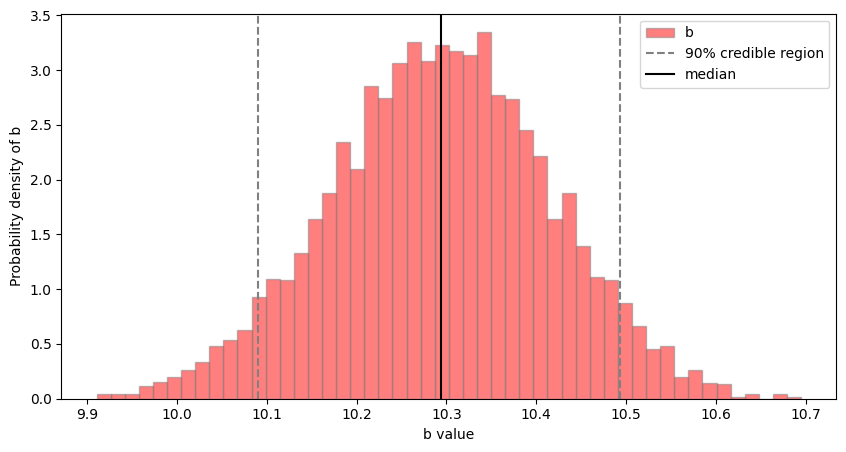

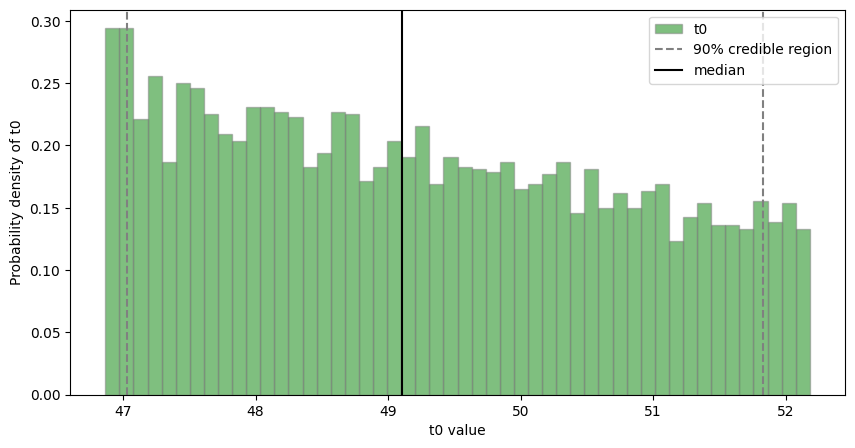

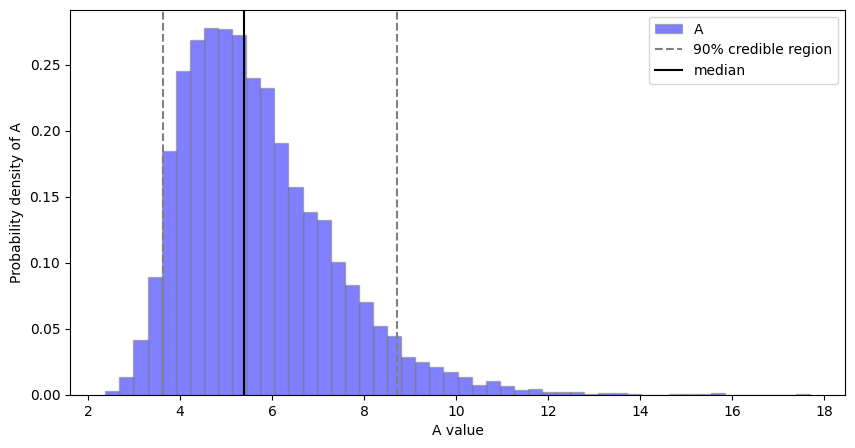

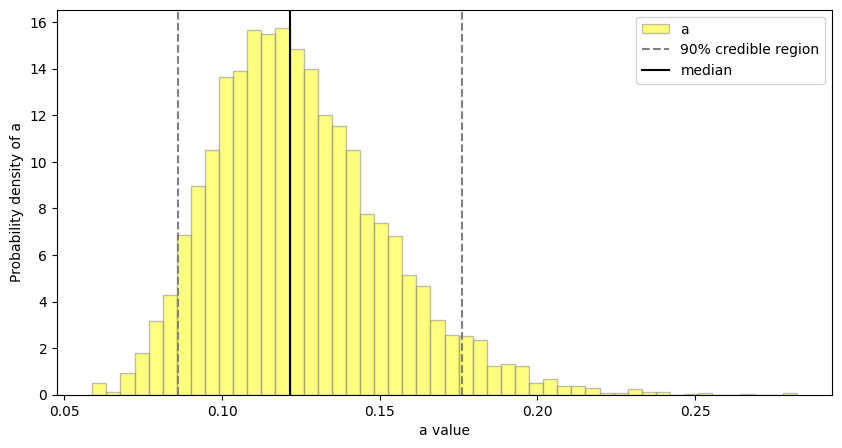

In [47]:
bins=[50, 50, 50, 50]
plt.figure(figsize=(10, 5))
plt.hist(flat_samples[:, 0], bins=bins[0], color="red", edgecolor="gray", density=True, label=labels[0], alpha=0.5)
plt.axvline(b_q05, color="gray", linestyle="--", label="90% credible region")
plt.axvline(b_q50, color="black", linestyle="-", label="median")
plt.axvline(b_q95, color="gray", linestyle="--")
plt.xlabel(labels[0]+" value")
plt.ylabel("Probability density of "+labels[0])
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(flat_samples[:, 1], bins=bins[1], color="green", edgecolor="gray", density=True, label=labels[1], alpha=0.5)
plt.axvline(t0_q05, color="gray", linestyle="--", label="90% credible region")
plt.axvline(t0_q50, color="black", linestyle="-", label="median")
plt.axvline(t0_q95, color="gray", linestyle="--")
plt.xlabel(labels[1]+" value")
plt.ylabel("Probability density of "+labels[1])
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(flat_samples[:, 2], bins=bins[2], color="blue", edgecolor="gray", density=True, label=labels[2], alpha=0.5)
plt.axvline(A_q05, color="gray", linestyle="--", label="90% credible region")
plt.axvline(A_q50, color="black", linestyle="-", label="median")
plt.axvline(A_q95, color="gray", linestyle="--")
plt.xlabel(labels[2]+" value")
plt.ylabel("Probability density of "+labels[2])
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(flat_samples[:, 3], bins=bins[3], color="yellow", edgecolor="gray", density=True, label=labels[3], alpha=0.5)
plt.axvline(a_q05, color="gray", linestyle="--", label="90% credible region")
plt.axvline(a_q50, color="black", linestyle="-", label="median")
plt.axvline(a_q95, color="gray", linestyle="--")
plt.xlabel(labels[3]+" value")
plt.ylabel("Probability density of "+labels[3])
plt.legend()
plt.show()

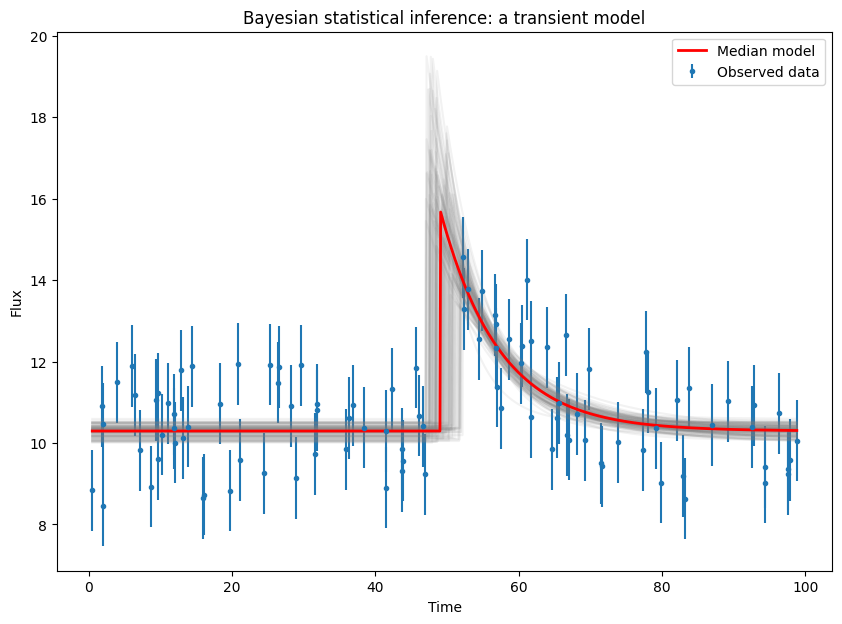

In [59]:
x_fit = np.linspace(min(time), max(time), 1000)
y_median = model(x_fit, [b_q50, t0_q50, A_q50, a_q50])

plt.figure(figsize=(10, 7))
# Plot the observed data
plt.errorbar(time, flux, yerr=flux_err, fmt='.', label="Observed data")
# Plot a few random samples from posterior
for s in flat_samples[np.random.choice(len(flat_samples), size=100, replace=False)]:
  plt.plot(x_fit, model(x_fit, s), color='gray', alpha=0.1)
# Plot the median model
plt.plot(x_fit, y_median, lw=2, color="red", label="Median model")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Bayesian statistical inference: a transient model")
plt.legend()
plt.show()

In [86]:
# Printing parameters estimation
output_lines = [r"\begin{aligned}"]
for i, label in enumerate(labels):
    p05, p50, p95 = np.percentile(flat_samples[:, i], [5, 50, 95])
    lower = p50 - p05
    upper = p95 - p50
    output_lines.append(fr"\text{{{label}}} &= {p50:.3f}^{{+{upper:.3f}}}_{{-{lower:.3f}}} \\")
output_lines.append(r"\end{aligned}")

latex_block = "\n".join(output_lines)
display(Math(latex_block))

<IPython.core.display.Math object>